# Classification Problem - Dataset German Credit - Label Customer Credit Status

##
## Họ tên: Phan Thủy Tiên

<div>
<b style="font-size: 1.2em;">TABLE OF CONTENTS</b>

* [Step 1. Exploratory Data Analysis (EDA)](#step-1-exploratory-data-analysis-eda)
    * [1.1. Dataset Overview (Head & Info)](#11-dataset-overview-head--info)
    * [1.2. Descriptive Statistics (Describe)](#12-descriptive-statistics-describe)
    * [1.3. Distribution of Numerical and Categorical Features](#13-distribution-of-numerical-and-categorical-features)
    * [1.4. Correlation Analysis between Features and Target Variable](#14-correlation-analysis-between-features-and-target-variable)
* [Step 2. Data Preprocessing](#step-2-data-preprocessing)
    * [2.1. Data Quality](#21-data-quality)
    * [2.2. Categorical Features Encoding](#22-categorical-features-encoding)
    * [2.3. Train/Test Data Splitting](#23-traintest-data-splitting)
    * [2.4. Feature Scaling for Numerical Data](#24-feature-scaling-for-numerical-data)
    * [2.5. Handling Data Imbalance](#25-handling-data-imbalance)
* [Step 3. Model Building](#step-3-model-building)
    * [3.1. Model 1: Logistic Regression](#31-model-1-logistic-regression)
    * [3.2. Model 2: Random Forest](#32-model-2-random-forest)
    * [3.3. Model 3: Naive Bayes](#33-model-3-naive-bayes)
    * [3.4. Hyperparameter Tuning](#34-hyperparameter-tuning)
* [Step 4. Model Evaluation](#step-4-model-evaluation)
    * [4.1. Confusion Matrix Evaluation](#41-confusion-matrix-evaluation)
    * [4.2. Accuracy, Precision, Recall, and F1-Score Metrics Analysis](#42-accuracy-precision-recall-and-f1-score-metrics-analysis)
    * [4.3. ROC Curve and AUC Score Evaluation](#43-roc-curve-and-auc-score-evaluation)
* [Step 5. Result Comparison & Conclusion](#step-5-result-comparison--conclusion)
    * [5.1. Performance Comparison Table](#51-performance-comparison-table)
    * [5.2. Conclusion and Business Recommendations for the Bank](#52-conclusion-and-business-recommendations-for-the-bank)
</div>

### Library

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB  
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    roc_curve,
)

from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB

#### Dictionary
1. **laufkont**: Level of current balance in the client's account (1,2,3,4)
* *1* - little
* *2* - moderate
* *3* - rich
* *4* - no checking account
2. **laufzeit**: Loan repayment period (Unit: Months)
3. **moral**: History of compliance with past credit obligations (0,1,2,3,4)
* *0* - no credits taken / all credits paid back duly
* *1* - all credits at this bank paid back duly
* *2* - existing credits paid back duly till now
* *3* - delay in paying off in the past
* *4* - critical account / other credits existing (not at this bank)
4. **verw**: Purpose of the loan (0,1,2,3,4,5,6,8,9,10)
* *0* - car (new)
* *1* - car (used)
* *2* - furniture/equipment
* *3* - radio/television
* *4* - domestic appliances
* *5* - repairs
* *6* - education
* *8* - retraining
* *9* - business
* *10* - others
5. **hoehe**: Credit amount requested by the client (Unit: DM)
6. **sparkont**: Level of financial asset accumulation of an individual at the bank (1,2,3,4,5)
* *1* - < 100 DM (little)
* *2* - 100 <= ... < 500 DM (moderate)
* *3* - 500 <= ... < 1000 DM (quite rich)
* *4* - >= 1000 DM (rich)
* *5* - unknown / no savings account
7. **beszeit**: Present employment duration since (1,2,3,4,5)
* *1* - unemployed
* *2* - < 1 year
* *3* - 1 <= ... < 4 years
* *4* - 4 <= ... < 7 years
* *5* - >= 7 years
8. **rate**: Installment rate in percentage of disposable income (1,2,3,4)
9. **famges**: Marital status and biological gender of the individual (1,2,3,4,5)
* *1* - male : divorced / separated
* *2* - female : divorced / separated / married
* *3* - male : single
* *4* - male : married / widowed
* *5* - female : single
10. **buerge**: Other debtors or guarantors for the loan (1,2,3)
* *1* - none
* *2* - co-applicant
* *3* - guarantor
11. **wohnzeit**: Duration of living at the current residence (1,2,3,4)
12. **verm**: Financial or physical assets owned by the individual (1,2,3,4)
* *1* - real estate
* *2* - building society savings agreement / life insurance
* *3* - car or other (not in attribute 1 or 2)
* *4* - unknown / no property
13. **alter**: Age of an individual at the time of evaluation (e.g. 21,36,..)
14. **weitkred**: Other ongoing payment or installment plans (1,2,3)
* *1* - bank
* *2* - stores
* *3* - none
15. **wohn**: Housing ownership status of the individual (1,2,3)
* *1* - rent
* *2* - own
* *3* - for free
16. **bishkred**: Number of existing credits at this bank (including the current one)
17. **beruf**: Job skill level and residency status of the individual (1,2,3,4)
* *1* - unemployed / unskilled - non-resident
* *2* - unskilled - resident
* *3* - skilled employee / official
* *4* - management / self-employed / highly qualified employee
18. **pers**: Number of people being liable to provide maintenance for (1,2)
19. **telef**: Telephone registration status under the customer's name (1,2)
* *1* - none (no telephone registered)
* *2* - yes (registered under the customer's name)
20. **gastarb**: Foreign worker status of the individual (1,2)
* *1* - yes
* *2* - no
21. **kredit**: Credit risk classification status / Target variable (1,2)
* *1* - good credit risk
* *2* - bad credit risk

### Import dataset

In [2]:
df_credit = pd.read_csv("german_credit_data.csv")

<a id="11-dataset-overview-head--info"></a>
### 1. Exploratory Data Analysis (EDA)

<a id="11-dataset-overview-head--info"></a>
#### 1.1 Dataset Overview (Head & Info)

In [3]:
df_credit.head()

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [4]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   laufkont  1000 non-null   int64
 1   laufzeit  1000 non-null   int64
 2   moral     1000 non-null   int64
 3   verw      1000 non-null   int64
 4   hoehe     1000 non-null   int64
 5   sparkont  1000 non-null   int64
 6   beszeit   1000 non-null   int64
 7   rate      1000 non-null   int64
 8   famges    1000 non-null   int64
 9   buerge    1000 non-null   int64
 10  wohnzeit  1000 non-null   int64
 11  verm      1000 non-null   int64
 12  alter     1000 non-null   int64
 13  weitkred  1000 non-null   int64
 14  wohn      1000 non-null   int64
 15  bishkred  1000 non-null   int64
 16  beruf     1000 non-null   int64
 17  pers      1000 non-null   int64
 18  telef     1000 non-null   int64
 19  gastarb   1000 non-null   int64
 20  kredit    1000 non-null   int64
dtypes: int64(21)
memory usage: 164.2 KB


#### Change Columns Name from German to English

In [5]:
column_mapping = {
    "laufkont": "checking_account",
    "laufzeit": "duration",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "credit_amount",
    "sparkont": "savings_account",
    "beszeit": "employment_duration",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors_guarantors",
    "wohnzeit": "present_residence_since",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "number_credits",
    "beruf": "job",
    "pers": "number_dependents",
    "telef": "telephone",
    "gastarb": "foreign_worker",
    "kredit": "credit_risk",
}
df_credit.rename(columns=column_mapping, inplace=True)

In [6]:
df_credit.head()

,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors_guarantors,...,property,age,other_installment_plans,housing,number_credits,job,number_dependents,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


<a id="12-descriptive-statistics-describe"></a>
#### 1.2 Descriptive Statistics (Describe)

df_credit.describe()

<a id="13-distribution-of-numerical-and-categorical-features"></a>
#### 1.3 Distribution of Numerical and Categorical Features

In [7]:
# Selecting categorical features
categorical_data=df_credit.select_dtypes(include= 'object')
# Append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 0 categorical features: 

[]


In [8]:
# Selecting numerical features
numerical_data = df_credit.select_dtypes(include='number')
# Append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 21 numerical features: 

['checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_duration', 'installment_rate', 'personal_status_sex', 'other_debtors_guarantors', 'present_residence_since', 'property', 'age', 'other_installment_plans', 'housing', 'number_credits', 'job', 'number_dependents', 'telephone', 'foreign_worker', 'credit_risk']


**Note**: All the features type are numeric but features can be categorial so need to double check by plotting their distributions

#### Numerical features

In [9]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
checking_account,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_history,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
credit_amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
savings_account,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
employment_duration,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
personal_status_sex,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
other_debtors_guarantors,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0


All values seem to be valid

#### Distribution

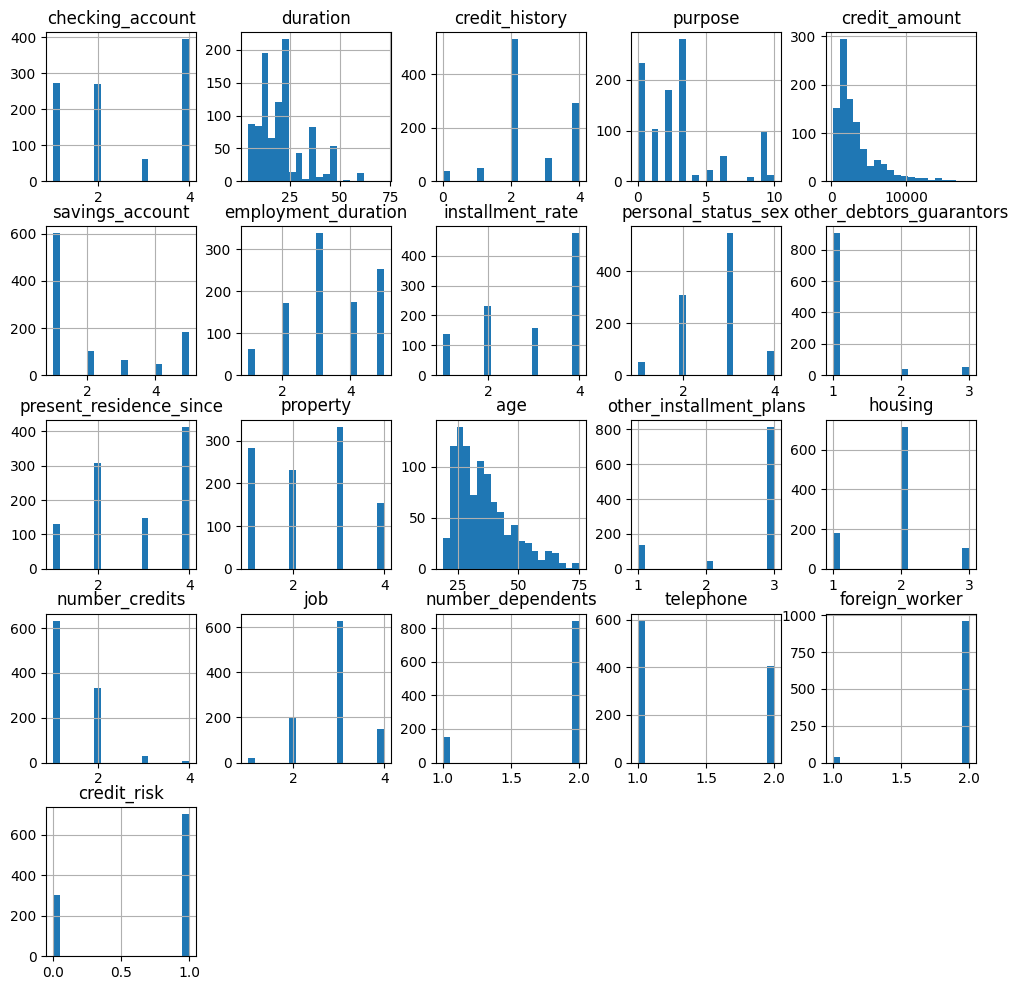

In [10]:
numerical_data.hist(figsize=(12,12),bins= 20)
plt.show()

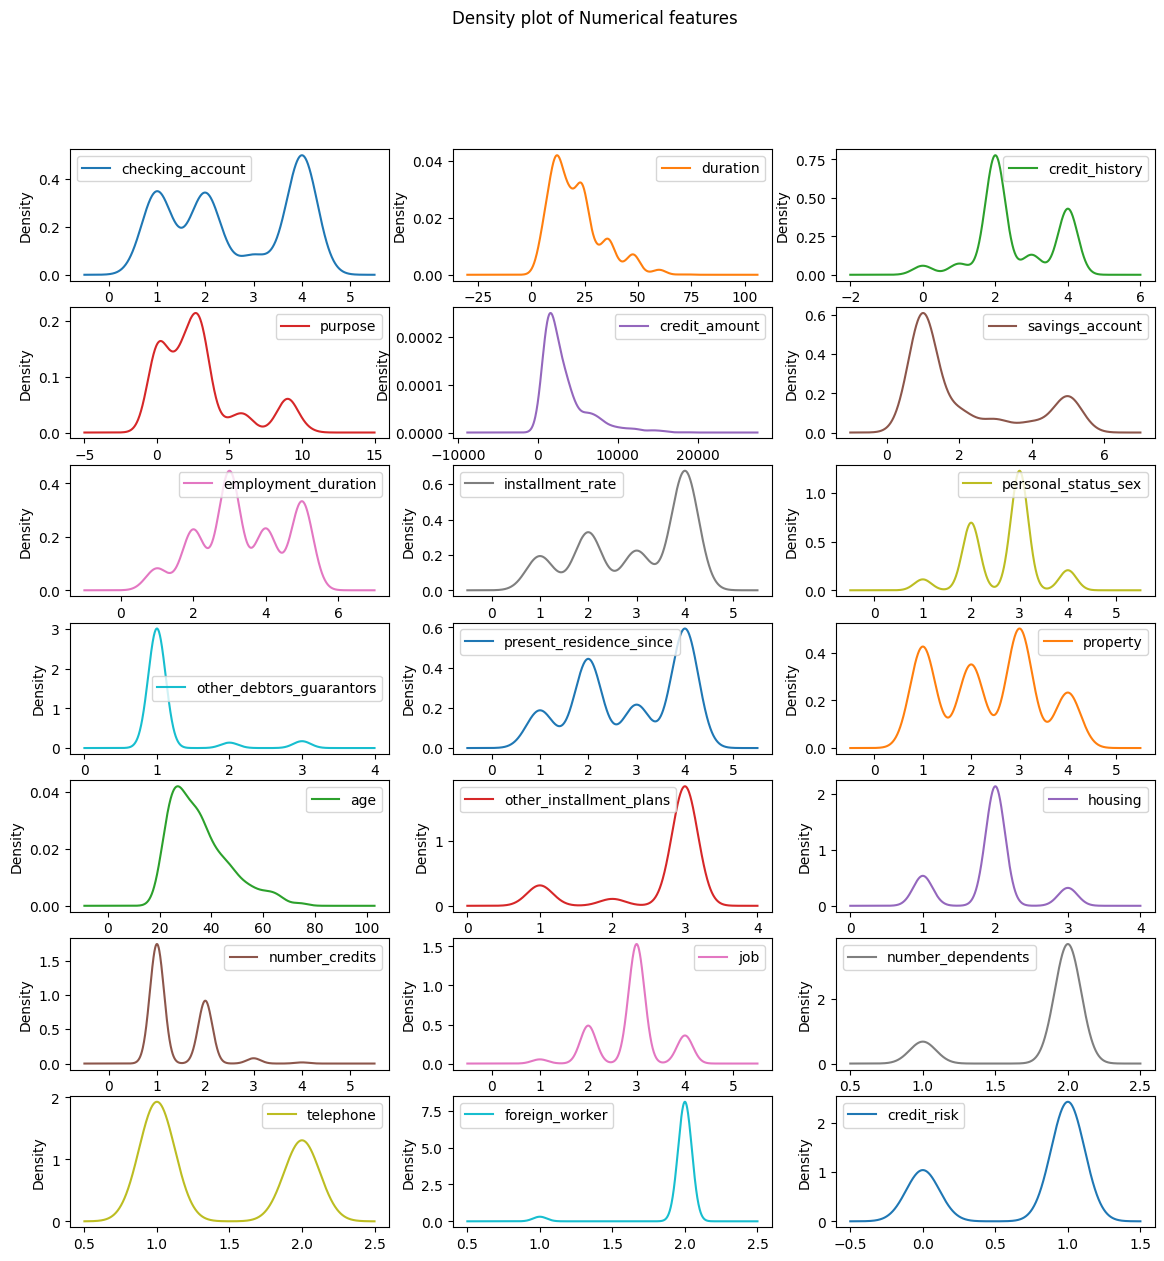

In [11]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(7,3),title="Density plot of Numerical features",sharex=False)
plt.show()

In [12]:
# Number Unique values in each feature
numerical_data.nunique()

checking_account              4
duration                     33
credit_history                5
purpose                      10
credit_amount               923
savings_account               5
employment_duration           5
installment_rate              4
personal_status_sex           4
other_debtors_guarantors      3
present_residence_since       4
property                      4
age                          53
other_installment_plans       3
housing                       3
number_credits                4
job                           4
number_dependents             2
telephone                     2
foreign_worker                2
credit_risk                   2
dtype: int64

**Note**:
Although they are all numeric values but only 'duration', 'age', 'credit_amount' are true numerical features as other are categorial features
* Especially Features 'number_dependents', 'telephone', 'foreign_worker' and our target 'credit_risk' are binary

In [13]:
# Missing Values¶
numerical_data.isnull().sum()

checking_account            0
duration                    0
credit_history              0
purpose                     0
credit_amount               0
savings_account             0
employment_duration         0
installment_rate            0
personal_status_sex         0
other_debtors_guarantors    0
present_residence_since     0
property                    0
age                         0
other_installment_plans     0
housing                     0
number_credits              0
job                         0
number_dependents           0
telephone                   0
foreign_worker              0
credit_risk                 0
dtype: int64

**Note**: Complete data

#### Categorical Features

#### Rerange True numerial features and categorial features

In [14]:
true_numerical_cols = ['duration', 'credit_amount', 'age']
categorical_features = [
    col for col in df_credit.columns if col not in true_numerical_cols
]
numerical_features = [col for col in numerical_features if col in true_numerical_cols]

In [15]:
categorical_features

['checking_account',
 'credit_history',
 'purpose',
 'savings_account',
 'employment_duration',
 'installment_rate',
 'personal_status_sex',
 'other_debtors_guarantors',
 'present_residence_since',
 'property',
 'other_installment_plans',
 'housing',
 'number_credits',
 'job',
 'number_dependents',
 'telephone',
 'foreign_worker',
 'credit_risk']

In [16]:
df_credit[categorical_features] = df_credit[categorical_features].astype("category")
print(df_credit.dtypes)

checking_account            category
duration                       int64
credit_history              category
purpose                     category
credit_amount                  int64
savings_account             category
employment_duration         category
installment_rate            category
personal_status_sex         category
other_debtors_guarantors    category
present_residence_since     category
property                    category
age                            int64
other_installment_plans     category
housing                     category
number_credits              category
job                         category
number_dependents           category
telephone                   category
foreign_worker              category
credit_risk                 category
dtype: object


In [17]:
categorical_data = df_credit[categorical_features]

In [18]:
# No of unique values in each categorical feature
unique_counts=categorical_data.nunique()

for index,i in enumerate(range(7),start=1):
    print(index,"{a} has {b} unique values".format(a=categorical_features[i],b=unique_counts[i]))

1 checking_account has 4 unique values
2 credit_history has 5 unique values
3 purpose has 10 unique values
4 savings_account has 5 unique values
5 employment_duration has 5 unique values
6 installment_rate has 4 unique values
7 personal_status_sex has 4 unique values


C:\Users\Admin\AppData\Local\Temp\ipykernel_14468\192792393.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(index,"{a} has {b} unique values".format(a=categorical_features[i],b=unique_counts[i]))


#### Plotting


checking_account



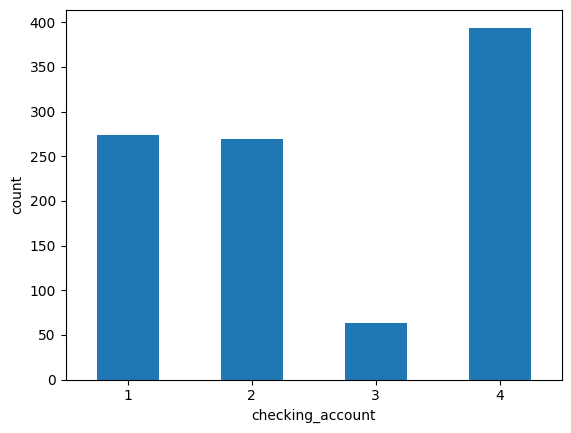


credit_history



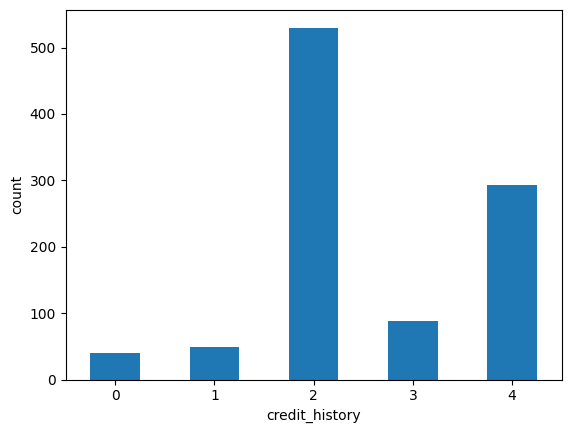


purpose



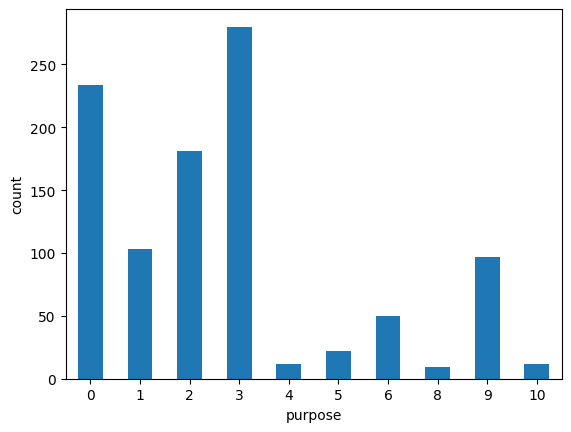


savings_account



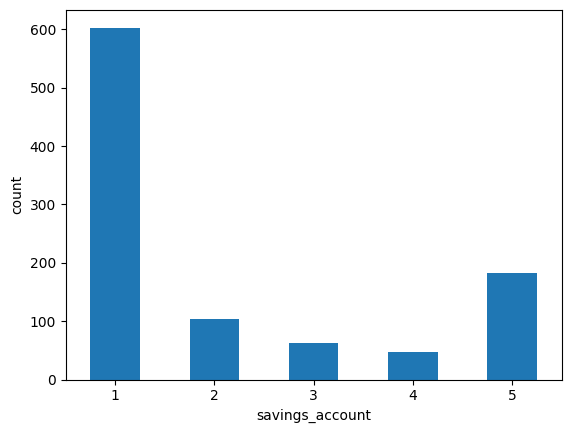


employment_duration



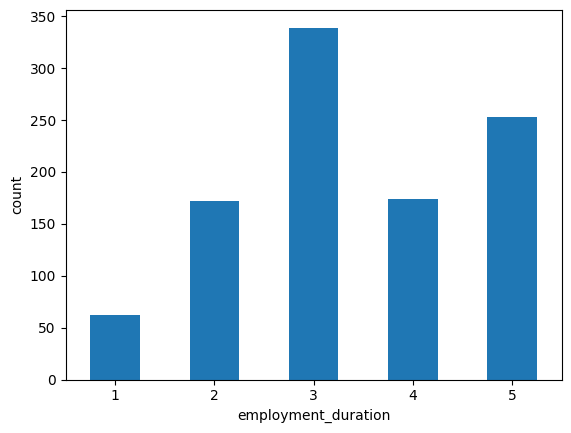


installment_rate



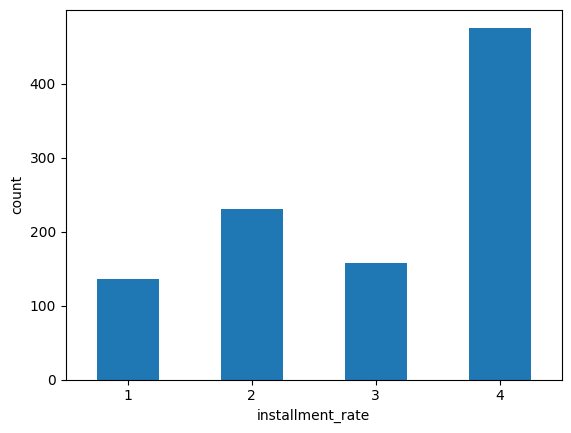


personal_status_sex



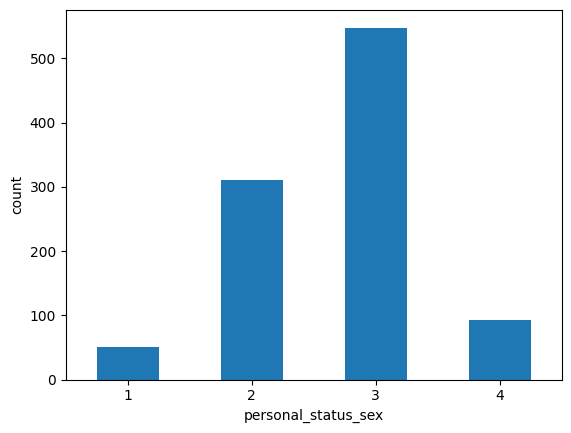


other_debtors_guarantors



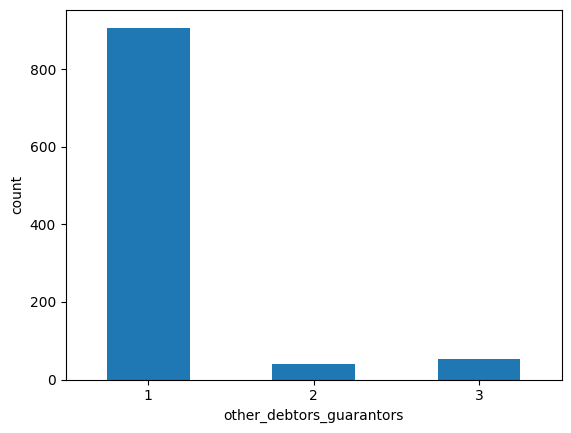


present_residence_since



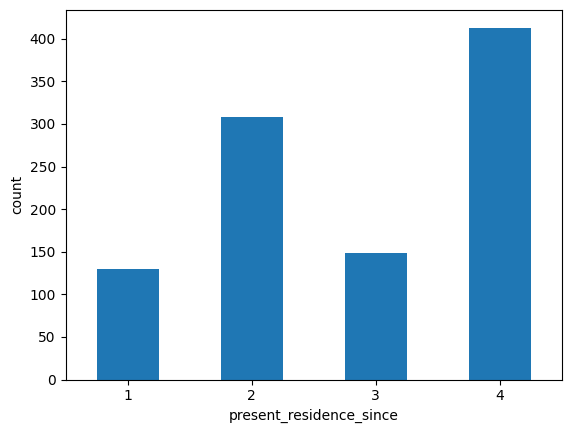


property



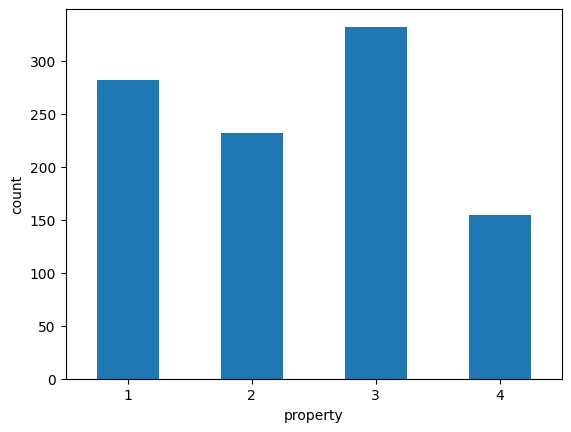


other_installment_plans



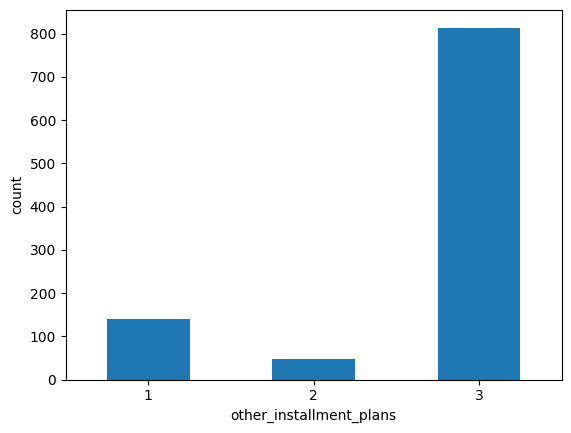


housing



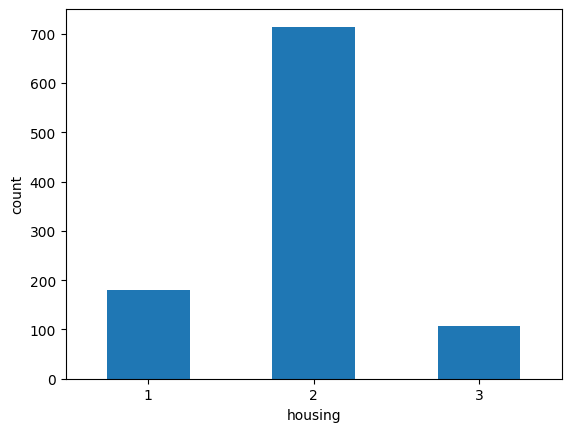


number_credits



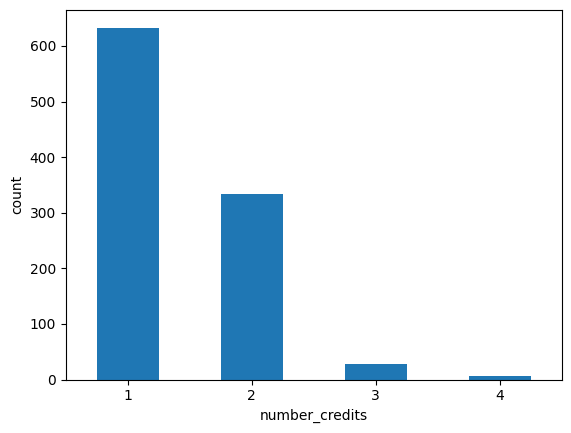


job



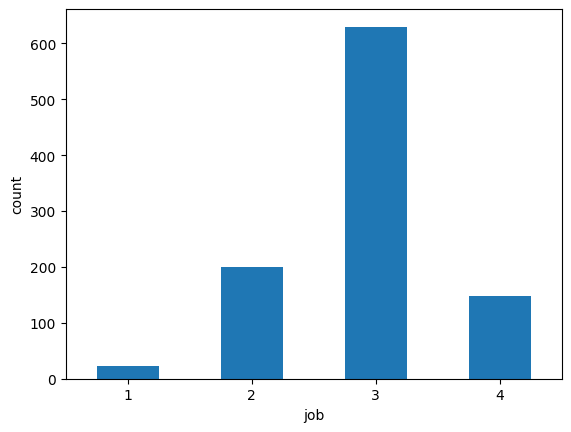


number_dependents



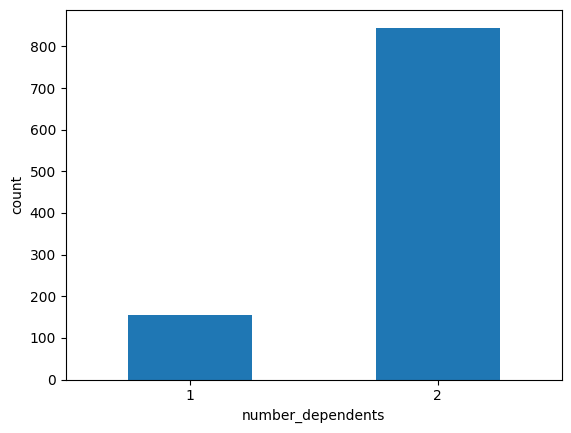


telephone



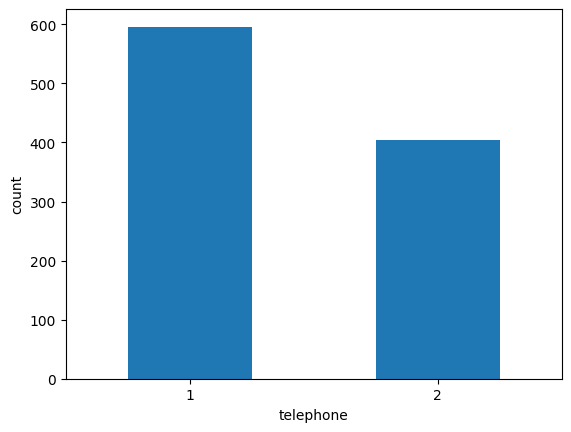


foreign_worker



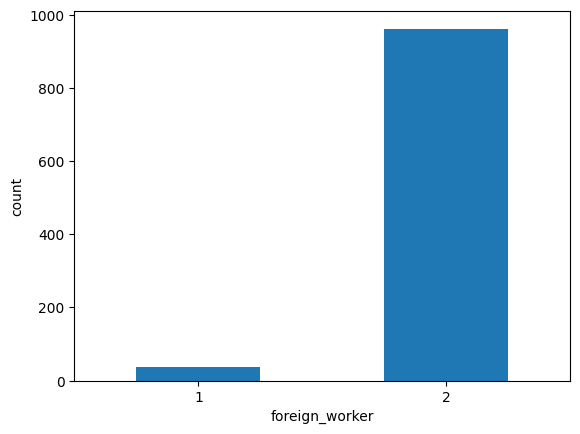


credit_risk



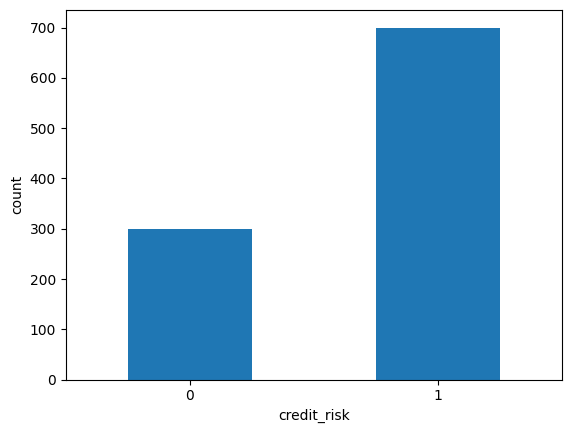

In [19]:
# Barplot of unique value counts in every categorical features
# through Looping generate bar plots of unqiue value counts in each variable
for col in categorical_features:
    print()
    print(f"\033[1m{col}\033[0m\n") #print column name above the plot
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

<a id="14-correlation-analysis-between-features-and-target-variable"></a>
#### 1.4 Correlation Analysis between Features and Target Variable

In [20]:
# Correlation matrix of whole dataset
# Generating correlation coefficient between each features
from pandas import set_option

# Set display precision
# Set the precision for float display
set_option('display.float_format', '{:,.3f}'.format)

# Ensure we're working with only numeric columns

# Calculate correlation matrix
correlation = numerical_data.corr(method='pearson')

# Display the correlation matrix
correlation


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate,personal_status_sex,other_debtors_guarantors,...,property,age,other_installment_plans,housing,number_credits,job,number_dependents,telephone,foreign_worker,credit_risk
checking_account,1.000,-0.072,0.192,0.029,-0.043,0.223,0.106,-0.005,0.043,-0.128,...,-0.032,0.059,0.068,0.023,0.076,0.041,0.014,0.066,0.035,0.351
duration,-0.072,1.000,-0.077,0.147,0.625,0.048,0.057,0.075,0.015,-0.024,...,0.304,-0.038,-0.063,0.153,-0.011,0.211,0.024,0.165,0.135,-0.215
credit_history,0.192,-0.077,1.000,-0.090,-0.060,0.039,0.138,0.044,0.042,-0.041,...,-0.054,0.146,0.160,0.061,0.437,0.010,-0.012,0.052,-0.029,0.229
purpose,0.029,0.147,-0.090,1.000,0.068,-0.019,0.016,0.048,0.000,-0.018,...,0.011,-0.001,-0.100,0.013,0.055,0.008,0.033,0.078,0.113,-0.018
credit_amount,-0.043,0.625,-0.060,0.068,1.000,0.065,-0.008,-0.271,-0.016,-0.028,...,0.312,0.032,-0.069,0.133,0.021,0.285,-0.017,0.277,0.031,-0.155
savings_account,0.223,0.048,0.039,-0.019,0.065,1.000,0.121,0.022,0.017,-0.105,...,0.019,0.083,0.002,0.007,-0.022,0.012,-0.028,0.087,-0.010,0.179
employment_duration,0.106,0.057,0.138,0.016,-0.008,0.121,1.000,0.126,0.111,-0.008,...,0.087,0.259,-0.007,0.115,0.126,0.101,-0.097,0.061,0.023,0.116
installment_rate,-0.005,0.075,0.044,0.048,-0.271,0.022,0.126,1.000,0.119,-0.011,...,0.053,0.057,0.008,0.091,0.022,0.098,0.071,0.014,0.095,-0.072
personal_status_sex,0.043,0.015,0.042,0.000,-0.016,0.017,0.111,0.119,1.000,0.051,...,-0.007,0.005,-0.027,0.099,0.065,-0.012,-0.122,0.027,-0.073,0.088
other_debtors_guarantors,-0.128,-0.024,-0.041,-0.018,-0.028,-0.105,-0.008,-0.011,0.051,1.000,...,-0.155,-0.030,-0.038,-0.065,-0.025,-0.058,-0.020,-0.075,-0.140,0.025


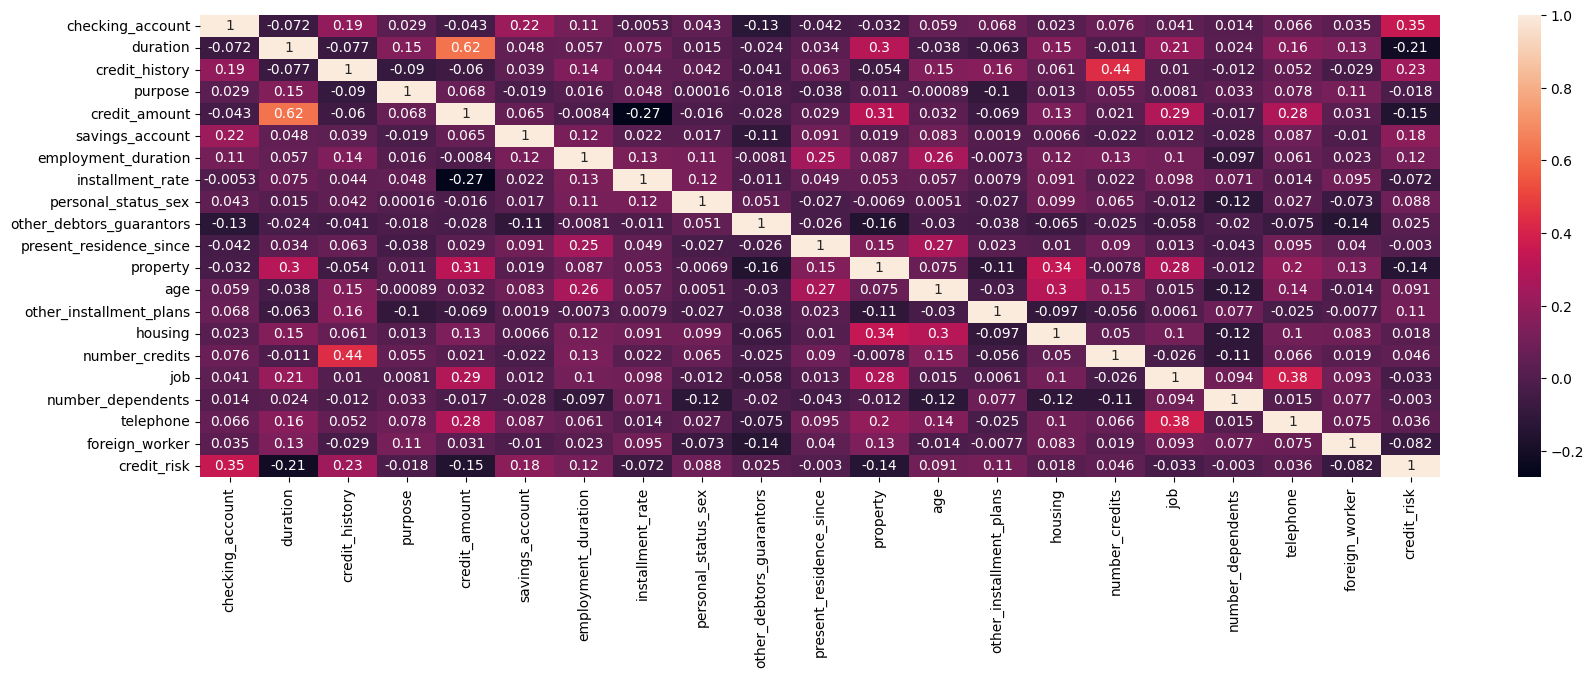

In [21]:
# Plot correlation matrix in heatmap
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(numerical_data.corr(), ax=ax, annot=True)
plt.show()

**Note**: Between input variables
* 'duration' and 'credit_amount' has a strong positive correlation (0.62): makes sense that the larger the loan, the more time the client needs 
* These couples have intermediate correlations are
* * 'credit_history' - 'number_credits' (0.44): Individuals with a specific credit history tend to have a larger number of loans at this bank
  * 'job' - 'telephone' (0.38): The higher the job/position level (job progressing to level 3 - highly skilled), the greater the chance of owning a    phone registered in the client's name
  * 'property' - 'housing' (0.34): a strong correlation between the type of property owned (if it's real estate) and the current form of housing (rented or owned)
  * 'property' - 'credit_amount' (0.31): Customers with high-value collateral are often approved for loans, or have a need for larger loan amounts.
  * 'employment_duration' - 'age' (0.26): Older people tend to have more years of experience at their current job than the younger

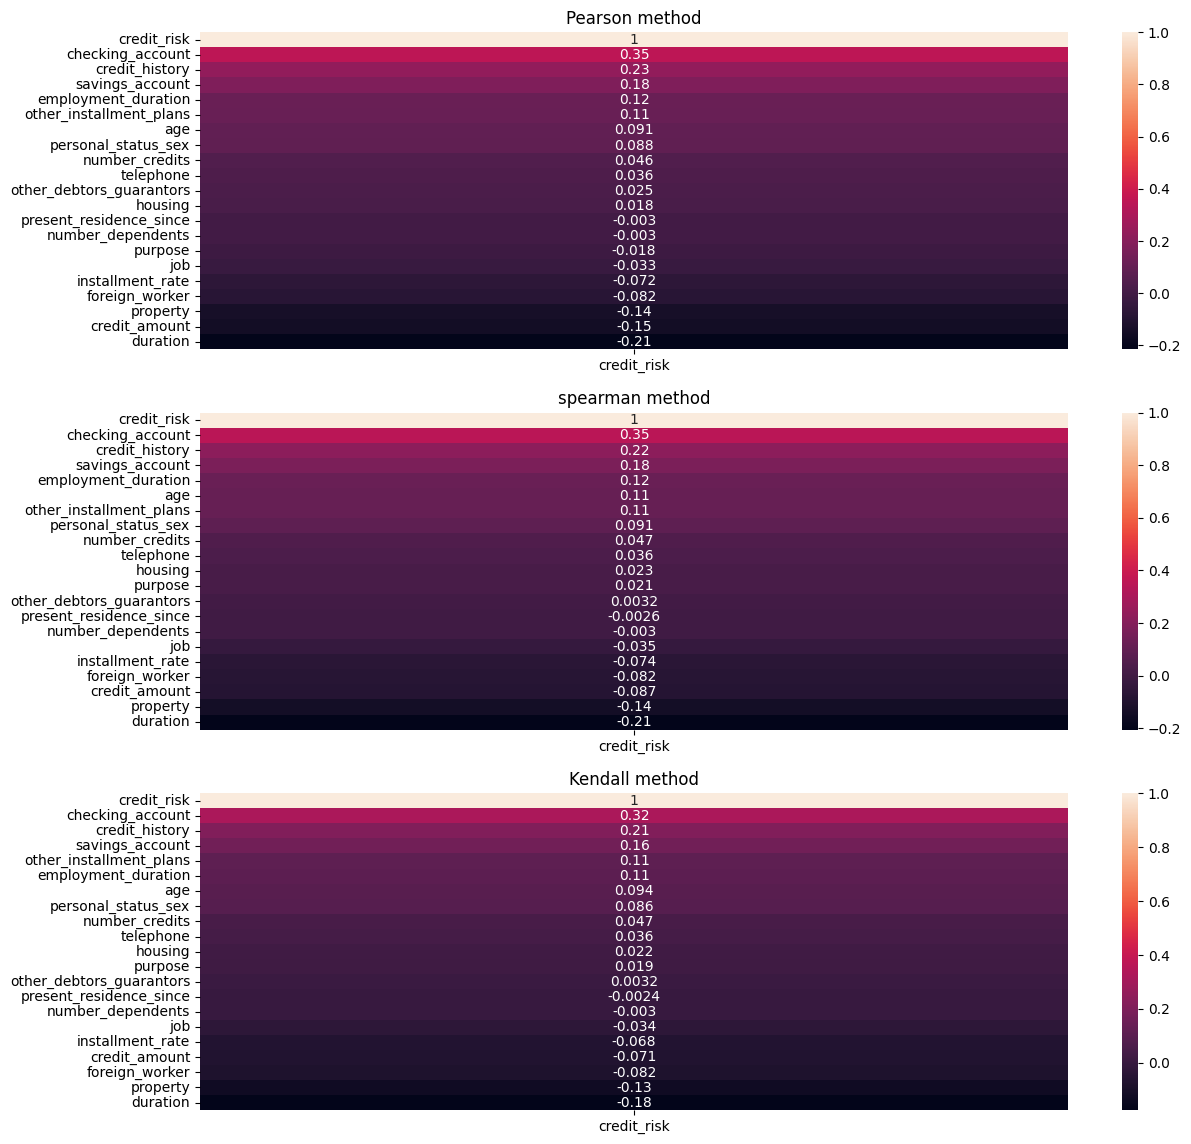

In [22]:
# Correlation plot between numerical features and target
fig, ax = plt.subplots(3,1, figsize=(14, 14))
## Correlation coefficient using different methods
corr1 = numerical_data.corr('pearson')[['credit_risk']].sort_values(by='credit_risk', ascending=False)
corr2 = numerical_data.corr('spearman')[['credit_risk']].sort_values(by='credit_risk', ascending=False)
corr3 = numerical_data.corr('kendall')[['credit_risk']].sort_values(by='credit_risk', ascending=False)

#setting titles for each plot
ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')
## Generating heatmaps of each methods
sns.heatmap(corr1, ax=ax[0], annot=True)
sns.heatmap(corr2, ax=ax[1], annot=True)
sns.heatmap(corr3, ax=ax[2], annot=True)

plt.show()

**Note**: Between feature and target
* There is a consistency between 3 methods
  *  'checking_account' - 'credit_history' - 'savings_account' have strong positive correlations with target (0.3x - 0.2x - 0.1x): 
  *  'duration' is always the most negative variable (-0.21/-0.21/-0.18)
  *  Other have weak correlations with credit_risk

**Credit risk does not depend too strongly linearly on a single variable, but rather is a non-linear combination of many factors**

#### Check imbalance in the data

In [23]:
#check Imbalance in data

#group instances based on the classes in OUTCOME variable
class_counts=df_credit.groupby("credit_risk").size()

columns=['credit_risk','count','percentage']
outcome=[0,1]
count=list()
percentage=list()

#Calculate the percentage of each value of the OUTCOME variable from total
for val in range(2):
    count.append(class_counts[val])
    percent=(class_counts[val]/105000)*100
    percentage.append(percent)

# Convert the calulated values into a dataframe
imbalance_df=pd.DataFrame(list(zip(outcome,count,percentage)),columns=columns)
imbalance_df

C:\Users\Admin\AppData\Local\Temp\ipykernel_14468\3382166632.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_counts=df_credit.groupby("credit_risk").size()


,credit_risk,count,percentage
0,0,300,0.286
1,1,700,0.667


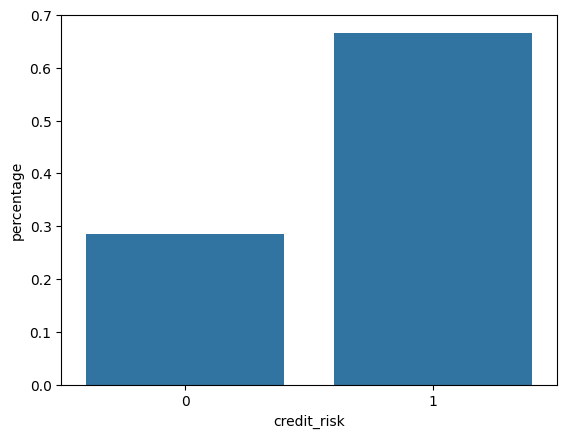

In [24]:
sns.barplot(data=imbalance_df,x=imbalance_df['credit_risk'],y=imbalance_df['percentage'])
plt.show()

**Note**:
- Based on the above grouping, It shows that around 70% of instances consists 'credit_risk' value '1' as good versus 30% of instances consists '0' as bad
- There is imbalance between two classes (more than 2 times). So consider adapting performance metrics like "recall", "precision" and "f1 score" instead of "accurary" to assess the ML model. Also check if the imbalance data affecting the performance of the machine learning model

<a id="step-2-data-preprocessing"></a>
### 2.  Data Preprocessing

<a id="21-data-quality"></a>
#### 2.1 Data Quality

In [25]:
# 1. Completeness: Checking and handling missing data
# Count missing values per column
df_credit.isnull().sum()

checking_account            0
duration                    0
credit_history              0
purpose                     0
credit_amount               0
savings_account             0
employment_duration         0
installment_rate            0
personal_status_sex         0
other_debtors_guarantors    0
present_residence_since     0
property                    0
age                         0
other_installment_plans     0
housing                     0
number_credits              0
job                         0
number_dependents           0
telephone                   0
foreign_worker              0
credit_risk                 0
dtype: int64

The dataset is complete

In [26]:
# 2. Accuracy 

The data is correct

In [27]:
# 3. Validity & Consistency

In [28]:
# As teleplone: 1 - none and 2 - yes -> Need to correct form 0 - none and 1 - yes
df_credit["telephone"] = df_credit["telephone"].map({1: 0, 2: 1})

#  As foreign_worker: 1 - yes and 2 - none -> Need to correct form 0 - none and 1 - yes
df_credit["foreign_worker"] = df_credit["foreign_worker"].map({1: 1, 2: 0})

Dataset is valid now

In [29]:
# 4. Timeless

There is no time variable in dataset

In [30]:
# 5. Uniqueness

In [31]:
df_credit.duplicated().sum()

np.int64(0)

There is no duplicate rows in dataset

<a id="22-categorical-features-encoding"></a>
#### 2.2 Categorical Features Encoding

In [32]:
# Use One-Hot Encoding and Ordinal Encoding

In [33]:
# Ordinal features
ordinal_cols = [
    "savings_account",
    "employment_duration",
    "installment_rate",
    "present_residence_since",
    "property",
    "number_credits",
    "job",
    "number_dependents",
    "telephone",
    "foreign_worker",
]

df_credit[ordinal_cols] = df_credit[ordinal_cols].astype("int64")

In [34]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   checking_account          1000 non-null   category
 1   duration                  1000 non-null   int64   
 2   credit_history            1000 non-null   category
 3   purpose                   1000 non-null   category
 4   credit_amount             1000 non-null   int64   
 5   savings_account           1000 non-null   int64   
 6   employment_duration       1000 non-null   int64   
 7   installment_rate          1000 non-null   int64   
 8   personal_status_sex       1000 non-null   category
 9   other_debtors_guarantors  1000 non-null   category
 10  present_residence_since   1000 non-null   int64   
 11  property                  1000 non-null   int64   
 12  age                       1000 non-null   int64   
 13  other_installment_plans   1000 non-null   categor

In [35]:
# Nomial features
nominal_cols = [
    "checking_account",
    "credit_history",
    "purpose",
    "personal_status_sex",
    "housing",
    "other_debtors_guarantors", 
    "other_installment_plans",
]

# One-Hot Encoding automated
df_final = pd.get_dummies(df_credit, columns=nominal_cols, drop_first=True, dtype=int)

# Reset index
df_final = df_final.reset_index(drop=True)

In [36]:
df_final.head()

,duration,credit_amount,savings_account,employment_duration,installment_rate,present_residence_since,property,age,number_credits,job,...,purpose_10,personal_status_sex_2,personal_status_sex_3,personal_status_sex_4,housing_2,housing_3,other_debtors_guarantors_2,other_debtors_guarantors_3,other_installment_plans_2,other_installment_plans_3
0,18,1049,1,2,4,4,2,21,1,3,...,0,1,0,0,0,0,0,0,0,1
1,9,2799,1,3,2,2,1,36,2,3,...,0,0,1,0,0,0,0,0,0,1
2,12,841,2,4,2,4,1,23,1,2,...,0,1,0,0,0,0,0,0,0,1
3,12,2122,1,3,3,2,1,39,2,2,...,0,0,1,0,0,0,0,0,0,1
4,12,2171,1,3,4,4,2,38,2,2,...,0,0,1,0,1,0,0,0,0,0


<a id="23-traintest-data-splitting"></a>
#### 2.3 Train/Test Data Splitting

In [37]:
# Split Train (80%) and Test (20%)
X = df_final.drop(columns=["credit_risk"])
y = df_final["credit_risk"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<a id="24-feature-scaling-for-numerical-data"></a>
#### 2.4 Feature Scaling for Numerical Data

In [38]:
numerical_features

['duration', 'credit_amount', 'age']

In [39]:
# Make a copy to avoid direct overwriting lead to errors in the data slice 
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()

# Scaling
scaler = StandardScaler()

# fit and transform on train
X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Only tranform on test
X_val_scaled[numerical_features] = scaler.transform(X_val[numerical_features])

<a id="25-handling-data-imbalance"></a>
#### 2.5 Handling Data Imbalance

In [40]:
# Applying Handling Imbalance SMOTE on Train only
# Create SMOTE
smote = SMOTE(random_state=42)

# fit and resample on train only after scale
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

# Return NumPy Array to DataFrame to keep Header
X_train_balanced = pd.DataFrame(
    X_train_balanced, columns=X_train_scaled.columns
)

# Double check
print("Label distribution on Train befor SMOTE:")
print(y_train.value_counts())
print("\nLabel distribution on Train befor SMOTE:")
print(y_train_balanced.value_counts())

Label distribution on Train befor SMOTE:
credit_risk
1    560
0    240
Name: count, dtype: int64

Label distribution on Train befor SMOTE:
credit_risk
0    560
1    560
Name: count, dtype: int64


<a id="step-3-model-building"></a>
### 3. Model Building

<a id="31-model-1-logistic-regression"></a>
#### 3.1. Model 1: Logistic Regression

In [41]:
# Add max_iter=1000 to ensure algorithm gradient descent have enough loops to convering
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Train model
log_reg.fit(X_train_balanced, y_train_balanced)

# Prediction on Test set after scaling
y_pred = log_reg.predict(X_val_scaled)

# Predict probability of label 1 (Good) to evaluate ROC-AUC
y_pred_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

<a id="32-model-2-random-forest"></a>
#### 3.2. Model 2: Random Forest

In [42]:
# Call Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = 6, min_samples_split = 4, random_state = 42)

# Train RF model on train set after scaling và balance by SMOTE
rf_model.fit(X_train_balanced, y_train_balanced)

# Prediction on test set after scaling
y_pred_rf = rf_model.predict(X_val_scaled)

# Predict probability of label 1 (Good) to evaluate ROC-AUC
y_pred_proba_rf = rf_model.predict_proba(X_val_scaled)[:, 1]


<a id="33-model-3-naive-bayes"></a>
#### 3.3. Model 3: Naive Bayes

In [43]:
# Call Naive Bayes 
nb_model = GaussianNB()

# Train RF model on train set after scaling và balance by SMOTE
nb_model.fit(X_train_balanced, y_train_balanced)

# Prediction on test set after scaling
y_pred_nb = nb_model.predict(X_val_scaled)

# Predict probability of label 1 (Good) to evaluate ROC-AUC
y_pred_proba_nb = nb_model.predict_proba(X_val_scaled)[:, 1]

<a id="step-4-model-evaluation"></a>
### 4. Model Evaluation

<a id="41-confusion-matrix-evaluation"></a>
#### 4.1 Confusion Matrix Evaluation
<a id="42-accuracy-precision-recall-and-f1-score metrics-analysis"></a>
#### 4.2 Accuracy, Precision, Recall, and F1-Score Metrics Analysis
<a id="43-roc-curve-and-auc-score-evaluation"></a>
#### 4.3 ROC Curve and AUC Score Evaluation

**LOGISTIC REGRESSION**

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.62      0.63      0.63        60
           1       0.84      0.84      0.84       140

    accuracy                           0.78       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.78      0.78      0.78       200

ROC-AUC Score: 0.8158


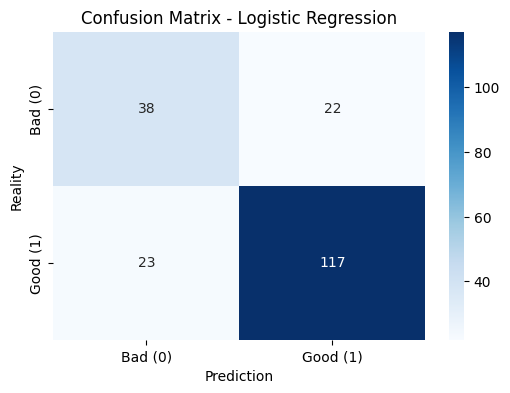

In [44]:
# Report on Precision, Recall, F1-score
print("CLASSIFICATION REPORT")
print(classification_report(y_val, y_pred))

# ROC-AUC point
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Visualize confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad (0)", "Good (1)"],
    yticklabels=["Bad (0)", "Good (1)"],
)

plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

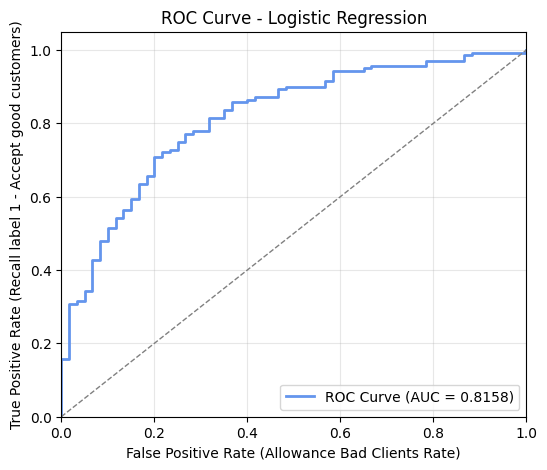

In [45]:
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)

# ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='cornflowerblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Random Guess - AUC = 0.5
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Allowance Bad Clients Rate)')
plt.ylabel('True Positive Rate (Recall label 1 - Accept good customers)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Note**: 
* Overview:
  * The ROC-AUC Score: 0.8158 seems good
  * The accuracy = 78%, the macro avg = 73% and the weighted avg = 78%
  * -> acceptable, model is not underfitting or overfitting
* Details:
  * Good labeing: Recall = 84% and Precision = 84% are high and even which proves that model good customer identification is highly sensitive and accurate, helping banks maintain a large and loyal customer base for profitability
  * Bad labeling: Recall = 63% and Precision = 62% are even but only upper-intermediate so 37% (23 people) slipped through the net and made it to the loan approval group, while 38% good customer were rejected (which means 22 good people were mistakenly denied)

**RANDOM FOREST**

CLASSIFICATION REPORT - RANDOM FOREST
              precision    recall  f1-score   support

           0       0.63      0.73      0.68        60
           1       0.88      0.81      0.84       140

    accuracy                           0.79       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.80      0.79      0.79       200

ROC-AUC Score: 0.8315


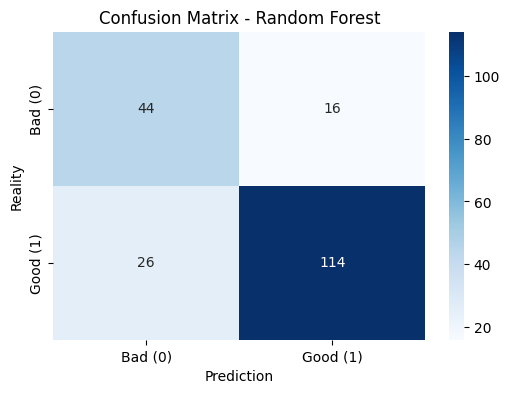

In [46]:
# Report on Precision, Recall, F1-score
print("CLASSIFICATION REPORT - RANDOM FOREST")
print(classification_report(y_val, y_pred_rf))

# ROC-AUC point
roc_auc_rf = roc_auc_score(y_val, y_pred_proba_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

# Ploting Confusion Matrix
cm_rf = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",  
    xticklabels=["Bad (0)", "Good (1)"],
    yticklabels=["Bad (0)", "Good (1)"],
)
plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion Matrix - Random Forest")
plt.show()

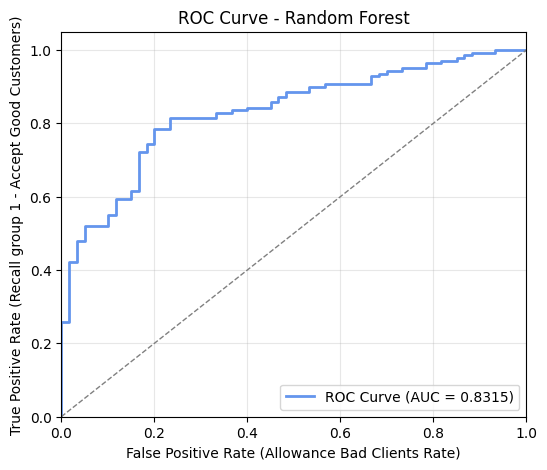

In [47]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_proba_rf)
roc_auc_rf = roc_auc_score(y_val, y_pred_proba_rf)


plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, color='cornflowerblue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Allowance Bad Clients Rate)')
plt.ylabel('True Positive Rate (Recall group 1 - Accept Good Customers)')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Note**: 
* Overview:
    * The ROC-AUC Score: 0.8315 seems good
    * The accuracy = 79%, the macro avg = 76% and the weighted avg = 79% -> acceptable, model is not underfitting or overfitting
* Details:
    * Good labeing: Recall = 81% and Precision = 88% are high and even which proves that model good customer identification is highly sensitive and accurate, helping banks maintain a large and loyal customer base for profitability
    * Bad labeling: Recall = 72% and Precision = 63% are approximately even but only upper-intermediate so 28% (16 people) slipped through the net and made it to the loan approval group, while 37% good customer were rejected (which means 26 good people were mistakenly denied)

**NAIVE BAYES**

CLASSIFICATION REPORT - NAIVE BAYES
              precision    recall  f1-score   support

           0       0.39      0.72      0.51        60
           1       0.81      0.52      0.63       140

    accuracy                           0.58       200
   macro avg       0.60      0.62      0.57       200
weighted avg       0.69      0.58      0.60       200

ROC-AUC Score: 0.7054


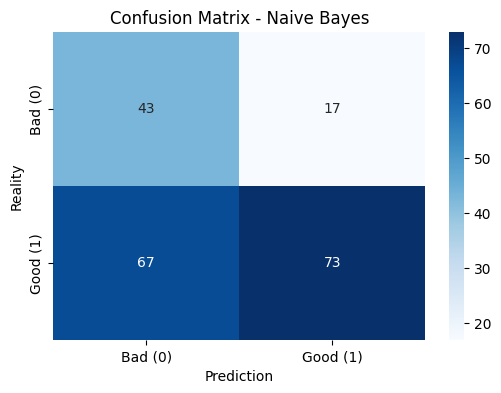

In [48]:
# Report on Precision, Recall, F1-score
print("CLASSIFICATION REPORT - NAIVE BAYES")
print(classification_report(y_val, y_pred_nb))

# ROC-AUC point
roc_auc_nb = roc_auc_score(y_val, y_pred_proba_nb)
print(f"ROC-AUC Score: {roc_auc_nb:.4f}")

# Ploting Confusion Matrix
cm_nb = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bad (0)", "Good (1)"],
    yticklabels=["Bad (0)", "Good (1)"],
)
plt.xlabel("Prediction")
plt.ylabel("Reality")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

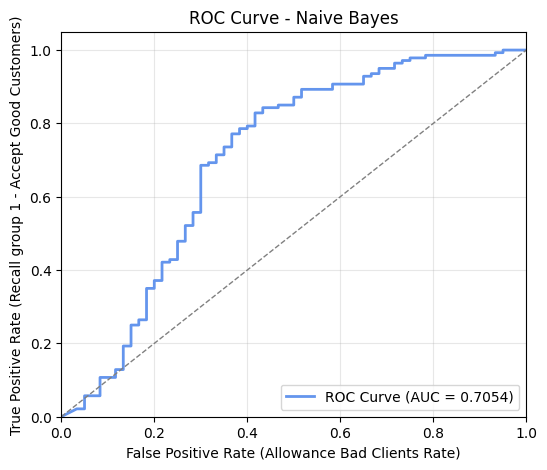

In [49]:
fpr_nb, tpr_nb, _ = roc_curve(y_val, y_pred_proba_nb)
roc_auc_nb = roc_auc_score(y_val, y_pred_proba_nb)


plt.figure(figsize=(6, 5))
plt.plot(fpr_nb, tpr_nb, color='cornflowerblue', lw=2, label=f'ROC Curve (AUC = {roc_auc_nb:.4f})')
plt.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Allowance Bad Clients Rate)')
plt.ylabel('True Positive Rate (Recall group 1 - Accept Good Customers)')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Note**: 
* Overview:
    * The ROC-AUC Score = 0.7054 is an upper-intermediate score
    * However, the accuracy = 58%, the macro avg = 57% and the weighted avg = 60%
    * -> unusual, model seems to be underfitting
* Details:
    * Good labeing: Recall = 52% and Precision = 81% are uneven which proves that model good customer identification is unsensitive so it accept a large of bad customer (17 actual bad customers to slip through the net)
    * Bad labeling: Recall = 72% and Precision = 39% are uneven. The recall metric is good but the model tend to be overreact so it accussed a large number of good clients to bad risk (67 good and potential clients were mistakenly denied)

<a id="step-5-result-comparison--conclusion"></a>
### 5. Result Comparison & Conclusion

<a id="51-performance-comparison-table"></a>
#### 5.1 Performance Comparison Table

In [50]:
# 1. Tạo một hàm nhỏ để tự động trích xuất các chỉ số cần thiết cho từng mô hình
# Create a function to metrics score
def get_model_metrics(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "ROC-AUC": round(roc_auc_score(y_true, y_prob), 4),
        "Accuracy": round(accuracy_score(y_true, y_pred), 2),
        "Precision (Bad-0)": round(precision_score(y_true, y_pred, pos_label=0), 2),
        "Recall (Bad-0)": round(recall_score(y_true, y_pred, pos_label=0), 2),
        "Precision (Good-1)": round(precision_score(y_true, y_pred, pos_label=1), 2),
        "Recall (Good-1)": round(recall_score(y_true, y_pred, pos_label=1), 2),
        "Macro Avg F1": round(f1_score(y_true, y_pred, average='macro'), 2)
    }


metrics_list = []
# Logistic Regression
metrics_list.append(get_model_metrics("Logistic Regression", y_val, y_pred, y_pred_proba))
# Random Forest
metrics_list.append(get_model_metrics("Random Forest", y_val, y_pred_rf, y_pred_proba_rf))
# Naive Bayes
metrics_list.append(get_model_metrics("Naive Bayes", y_val, y_pred_nb, y_pred_proba_nb))

# Reverse to data frame
df_comparison = pd.DataFrame(metrics_list)

display(df_comparison)

,Model,ROC-AUC,Accuracy,Precision (Bad-0),Recall (Bad-0),Precision (Good-1),Recall (Good-1),Macro Avg F1
0,Logistic Regression,0.816,0.780,0.620,0.630,0.840,0.840,0.730
1,Random Forest,0.832,0.790,0.630,0.730,0.880,0.810,0.760
2,Naive Bayes,0.705,0.580,0.390,0.720,0.810,0.520,0.570


<a id="52-conclusion-and-business-recommendations-for-the-bank"></a>
#### 5.2 Conclusion and Business Recommendations for the Bank

#### Conclusion

**Overview**: 
* Random Forest is the most optimal models in these three
* Logistic Regression is the second one
* Naive Bayes is the least due to underfitting
  
**Details**:
* **Random Forest** vs **Logistic Regression**
    * Random Forest holds a clear advantage in overall mathematical terms. Its ROC-AUC score is 0.8315 and its accuracy is 79%
    * Both the macro average and weighted average of Random Forest are higher than Logistic Regression by 1%
    * Random Forest won overwhelmingly with a Recall rate of 87% (approving 122 out of 140 good candidates). It only mistakenly rejected 18 good candidates while Logistic Regression unfairly rejected 23 good customers.
    * -> Choosing Random Forest allowed the bank to maximize its market capacity and not miss the opportunity to profit from 5 reputable customers who were subtly turned away by the old system.
    * The only advantage of Logistic Regression is it blocked 39 bad actors (Recall = 65%), letting only 21 defaulters slip through the net while Random Forest was a bit uncareful, only blocking 37 bad actors (Recall = 62%), letting 23 debt defaulters slip through the net


**In conclusion: Random Forest is the most suitable model for credit risk management objectives because it achieves the best balance between the ability to detect risky customers (Recall Bad = 0.73) and overall performance (ROC-AUC = 0.832, Accuracy = 0.79). Logistic Regression is a good alternative when explanatory power is prioritized. Naive Bayes is not suitable for implementation due to its excessively high false alarm rate.**

#### Business Recommendations for the Bank

1. Deploy Random Forest as the Primary Credit Risk Model
2. Optimize the Decision Threshold
3. Use Risk-Based Lending Rather Than Binary Approval
4. Keep Logistic Regression as a Benchmark Model
5. Incorporate Additional Customer Information
6. Regularly Monitor and Retrain the Model
7. Future Work: Applying advanced Models for the Dataset (Gradient Boosting, XGBoost, LightGBM, CatBoost, etc)